<a href="https://colab.research.google.com/github/nurilhuda05/PCVK_Ganjil_2026/blob/main/P6_17_Muhammad_Nuril_Huda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **CELL IDENTITAS**

In [1]:
NAMA = 'Muhammad Nuril Huda'
NIM = '244107020004'
print(NAMA, NIM)

Muhammad Nuril Huda 244107020004


# **D. PRAKTIKUM FILTER**

### **Import Library**

In [2]:
import cv2 as cv
import numpy as np
from matplotlib import pyplot as plt
import math
from google.colab.patches import cv2_imshow
from PIL import Image as im

### **Akses File**

In [3]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


### **Membuat Fungsi Konvolusi**

In [4]:
def convolution2d(image, kernel, stride, padding):

    image = np.pad(
        image,
        pad_width=padding,
        mode='constant',
        constant_values=0
    )

    kernel_height, kernel_width = kernel.shape
    image_height, image_width = image.shape

    output_height = int((image_height - kernel_height) / stride) + 1
    output_width = int((image_width - kernel_width) / stride) + 1

    output = np.zeros((output_height, output_width))

    for y in range(0, output_height):
        for x in range(0, output_width):

            region = image[
                y * stride:y * stride + kernel_height,
                x * stride:x * stride + kernel_width
            ]

            output[y, x] = np.sum(region * kernel)
    return output



### **Load Image**

In [5]:
img = cv.imread('/content/drive/MyDrive/Semester 5/PCVK/images/mandrill.tiff')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

### **Membuat Kernel Sharpen**

In [6]:
kernel_sharpen = np.array([[0,-1,0],
                           [-1,5,-1],
                           [0,-1,0]])

### **Memanggil Fungsi Konvolusi**

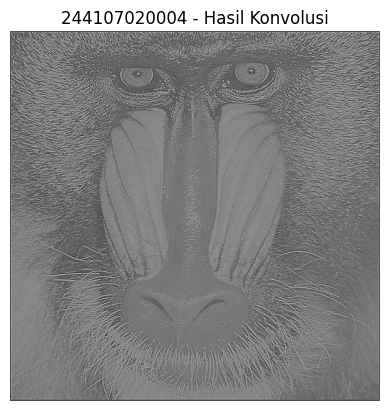

In [19]:
hasil_sharpen = convolution2d(img_gray, kernel_sharpen, 1, 2)

plt.imshow(hasil_sharpen, cmap='gray')
plt.title(NIM + ' - Hasil Konvolusi')
plt.axis('off')
plt.show()

### **Penerapan Beberapa Kernel**

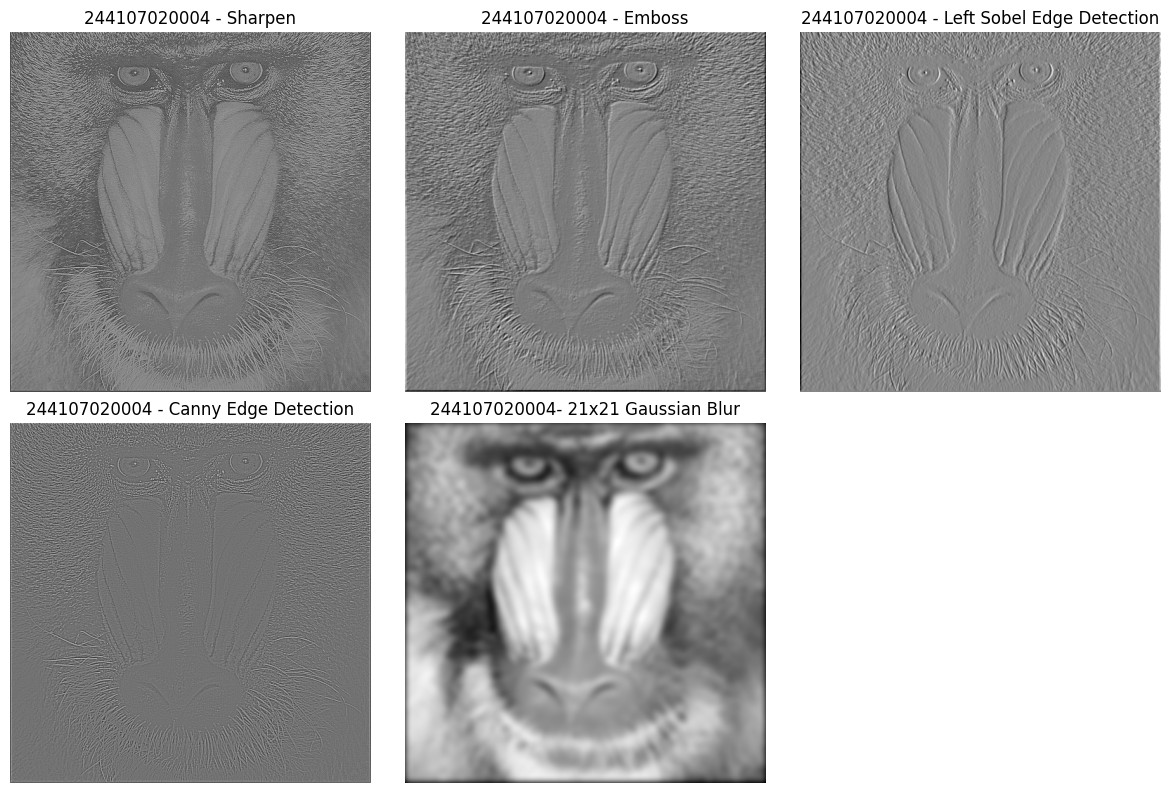

In [18]:
#Sharpen
kernel_sharpen = np.array([
    [0,-1,0],
    [-1,5,-1],
    [0,-1,0]
])

#Emboss
kernel_emboss = np.array([
    [-2,-1,0],
    [-1, 1,1],
    [ 0, 1,2]
])

#Left Sobel Edge Detection
kernel_sobel = np.array([
    [1,0,-1],
    [2,0,-2],
    [1,0,-1]
])

#Canny Edge Detection
kernel_canny = np.array([
    [-1,-1,-1],
    [-1, 8,-1],
    [-1,-1,-1]
])

#Gaussian Blur
kernel_size = 21
sigma = math.sqrt(kernel_size)
gaussian_kernel = cv.getGaussianKernel(kernel_size, sigma)
gauss_kernel = gaussian_kernel @ gaussian_kernel.transpose()

# Hasil
hasil_sharpen  = convolution2d(img_gray, kernel_sharpen, 1, 2)
hasil_emboss   = convolution2d(img_gray, kernel_emboss, 1, 2)
hasil_sobel    = convolution2d(img_gray, kernel_sobel, 1, 2)
hasil_canny    = convolution2d(img_gray, kernel_canny, 1, 2)
hasil_gaussian = convolution2d(img_gray, gauss_kernel, 1, 10)

# Menampilkan
plt.figure(figsize=(12,8))

plt.subplot(2,3,1)
plt.imshow(hasil_sharpen, cmap='gray')
plt.title(NIM + ' - Sharpen')
plt.axis('off')

plt.subplot(2,3,2)
plt.imshow(hasil_emboss, cmap='gray')
plt.title(NIM + ' - Emboss')
plt.axis('off')

plt.subplot(2,3,3)
plt.imshow(hasil_sobel, cmap='gray')
plt.title(NIM + ' - Left Sobel Edge Detection')
plt.axis('off')

plt.subplot(2,3,4)
plt.imshow(hasil_canny, cmap='gray')
plt.title(NIM + ' - Canny Edge Detection')
plt.axis('off')

plt.subplot(2,3,5)
plt.imshow(hasil_gaussian, cmap='gray')
plt.title(NIM + '- 21x21 Gaussian Blur')
plt.axis('off')

plt.tight_layout()
plt.show()

# **E. FILTER LIBRARY DAN FILTER MODERN**

### **Percobaan 1**

In [20]:
# Fungsi tampil berdampingan
def show_side_by_side(images, titles, figsize=(15,5)):
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles)):
        if len(img.shape) == 2:  # grayscale
            plt.subplot(1, len(images), i+1)
            plt.imshow(img, cmap='gray')
        else:  # color
            plt.subplot(1, len(images), i+1)
            plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis("off")
    plt.show()

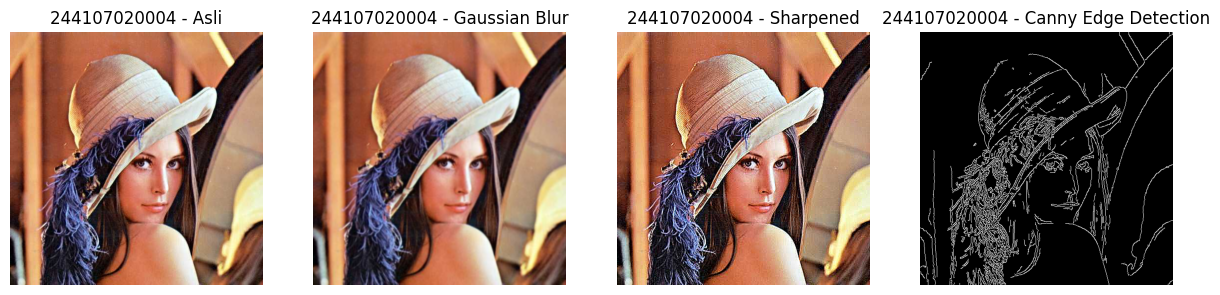

In [28]:
img = cv.imread('/content/drive/MyDrive/Semester 5/PCVK/images/lena.jpg')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

blur = cv.GaussianBlur(img, (7,7), 1)
edges = cv.Canny(img_gray, 100, 200)

sharpen_kernel = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]])
sharpened = cv.filter2D(img, -1, sharpen_kernel)

show_side_by_side([img, blur, sharpened, edges],
                  [NIM+" - Asli",
                   NIM+" - Gaussian Blur",
                   NIM+" - Sharpened",
                   NIM+" - Canny Edge Detection"])

### **Percobaan 2**

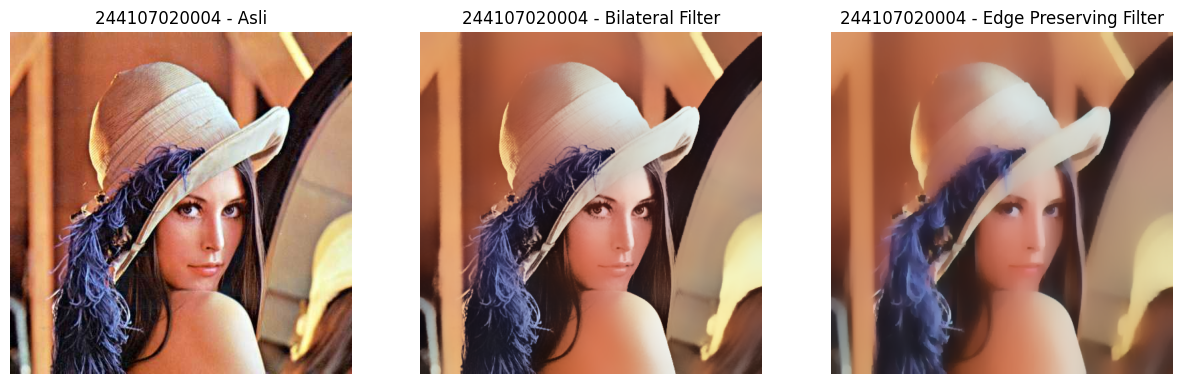

In [29]:
#Filter Modern dari OpenCV
# Bilateral Filter (edge-preserving)
bilateral = cv.bilateralFilter(img, 50, 100, 100)

# Edge Preserving Filter (alternatif Guided Filter)
edge_preserve = cv.edgePreservingFilter(img, flags=1, sigma_s=100, sigma_r=0.9)

show_side_by_side([img, bilateral, edge_preserve],
                  [NIM+" - Asli",
                   NIM+" - Bilateral Filter",
                   NIM+" - Edge Preserving Filter"])

### **Percobaan 3**

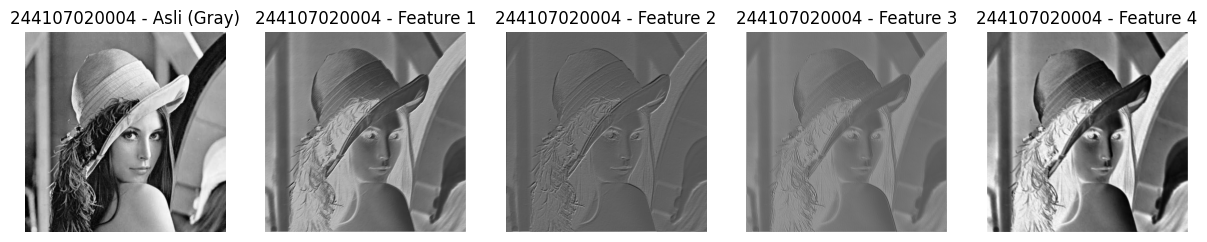

In [34]:
import torch
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 4, kernel_size=3, stride=1, padding=1)

    def forward(self, x):
        return self.conv1(x)

model = SimpleCNN()

# Ubah gambar ke tensor
img_tensor = torch.tensor(img_gray, dtype=torch.float32).unsqueeze(0).unsqueeze(0) / 255.0

# Hasil CNN
with torch.no_grad():
    features = model(img_tensor)

# Visualisasi feature maps
feature_maps = [features[0,i].numpy() for i in range(features.shape[1])]
show_side_by_side([img_gray] + feature_maps, [NIM+" - Asli (Gray)"] + [NIM+f" - Feature {i+1}" for i in range(len(feature_maps))])

Dari percobaan yang dilakukan, hasil Feature Map berbeda-beda setiap kali program dijalankan. Hal ini menunjukkan bahwa CNN dapat menghasilkan beberapa pola atau fitur yang berbeda dari satu gambar. Hasil feature map dapat berbeda pada setiap running karena bobot filter CNN diinisialisasi secara acak.

### **Percobaan 4**

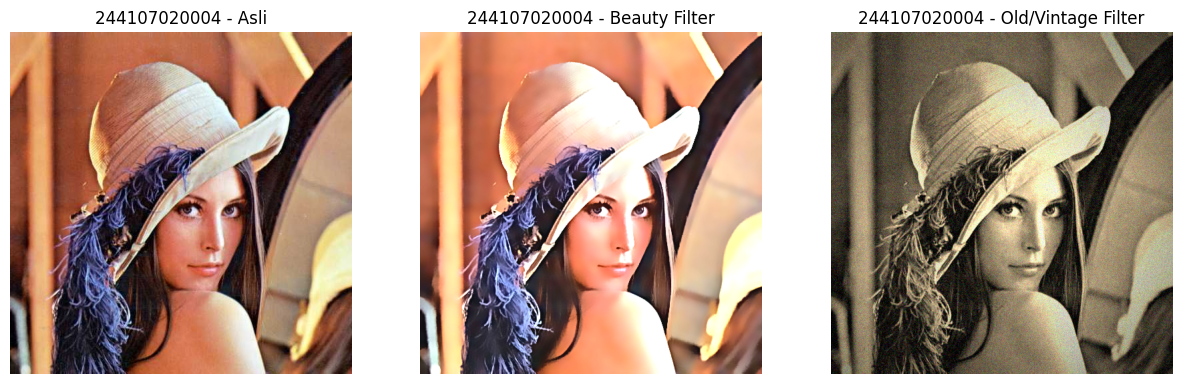

In [36]:
# ===================
# 1. Beauty Filter
# ===================

# Step 1: Smoothing kulit dengan bilateral filter
smooth = cv.bilateralFilter(img, d=15, sigmaColor=75, sigmaSpace=75)

# Step 2: Unsharp masking (pertajam mata/bibir)
gaussian = cv.GaussianBlur(smooth, (0,0), 3)
sharpened = cv.addWeighted(smooth, 1.5, gaussian, -0.5, 0)

# Step 3: Brightness & contrast
alpha = 1.2  # contrast
beta = 15    # brightness
beauty = cv.convertScaleAbs(sharpened, alpha=alpha, beta=beta)

# ===================
# 2. Old/Vintage Filter
# ===================

# Step 1: Sepia tone
sepia_kernel = np.array([[0.272, 0.534, 0.131],
                         [0.349, 0.686, 0.168],
                         [0.393, 0.769, 0.189]])

sepia = cv.transform(img, sepia_kernel)
sepia = np.clip(sepia, 0, 255).astype(np.uint8)

# Step 2: Vignette
rows, cols = img.shape[:2]
kernel_x = cv.getGaussianKernel(cols, cols*0.6)
kernel_y = cv.getGaussianKernel(rows, rows*0.6)
kernel = kernel_y * kernel_x.T
mask = kernel / kernel.max()
vignette = np.copy(sepia)
for i in range(3):
    vignette[:,:,i] = vignette[:,:,i] * mask

# Step 3: Noise/Grain
noise = np.random.normal(0, 15, vignette.shape).astype(np.int16)
old_img = np.clip(vignette.astype(np.int16) + noise, 0, 255).astype(np.uint8)


# Menampilkan
show_side_by_side(
    [img, beauty, old_img],
    [NIM+" - Asli",
     NIM+" - Beauty Filter",
     NIM+" - Old/Vintage Filter"]
)

### **Percobaan 5**

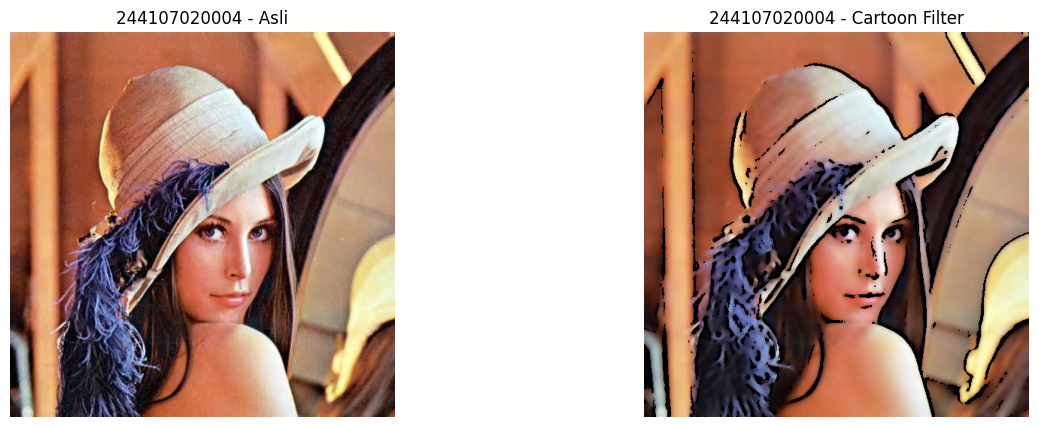

In [38]:
#Filter Anime / Cartoon
# Step 1: Edge detection (pakai median blur dulu agar gambar menjadi lebih halus)
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
gray_blur = cv.medianBlur(gray, 7)
edges = cv.adaptiveThreshold(gray_blur, 255,
                             cv.ADAPTIVE_THRESH_MEAN_C,
                             cv.THRESH_BINARY, 9, 9)

# Step 2: Bilateral filter untuk smoothing warna
color = cv.bilateralFilter(img, d=9, sigmaColor=200, sigmaSpace=200)

# Step 3: Gabungkan (cartoonize)
cartoon = cv.bitwise_and(color, color, mask=edges)

# Tampilkan
show_side_by_side([img, cartoon], [NIM+" - Asli",
                                   NIM+" - Cartoon Filter"])

### **Percobaan 6**

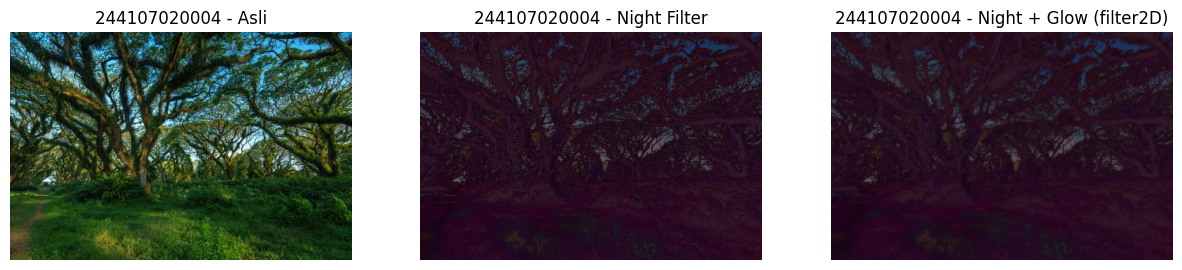

In [42]:
#Night Filter
img = cv.imread("/content/drive/MyDrive/Semester 5/PCVK/images/djawatan.jpg")
img_gray = cv.cvtColor(img,cv.COLOR_BGR2GRAY)

# Step 1: Gelapkan (contrast turun, brightness negatif)
night = cv.convertScaleAbs(img, alpha=0.6, beta=-40)

# Step 2: Tambah bias biru
blue_tint = np.full_like(night, (50, 0, 100))
night = cv.addWeighted(night, 0.8, blue_tint, 0.2, 0)

# Step 3: Efek Glow di area terang dengan filter2D (blur kernel)
kernel = np.ones((15,15), np.float32) / 225
glow = cv.filter2D(night, -1, kernel)

# Kombinasikan asli + glow
night_glow = cv.addWeighted(night, 0.7, glow, 0.3, 0)

show_side_by_side(
    [img, night, night_glow],
    [NIM+" - Asli",
     NIM+" - Night Filter",
     NIM+" - Night + Glow (filter2D)"]
)

### **Percobaan 7**

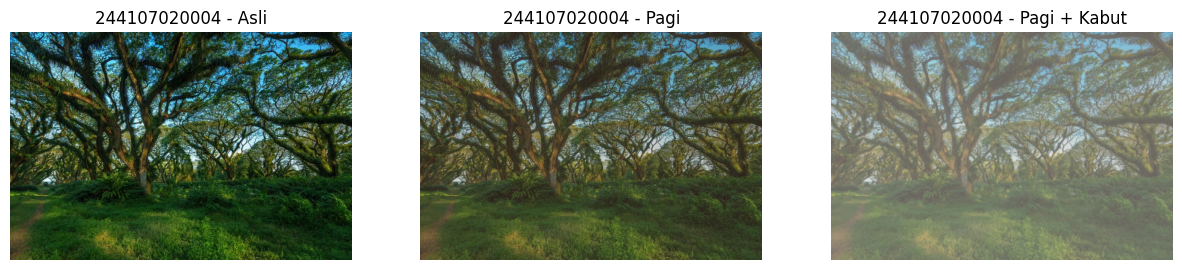

In [46]:
#Filter Suasana pagi dan Kabut
# =========================
# Step 1: Kurangi kontras & cerahkan
# =========================

alpha = 0.9    # contrast
beta = 20      # brightness
soft = cv.convertScaleAbs(img, alpha=alpha, beta=beta)

# =========================
# Step 2: Tambahkan warm tone (kemerahan / oranye)
# =========================
warm_tint = np.full_like(soft, (40, 70, 120))  # BGR
pagi = cv.addWeighted(soft, 0.8, warm_tint, 0.2, 0)

# =========================
# Step 3: Tambahkan haze (kabut tipis) dengan filter2D
# =========================
# Kernel blur Gaussian-like untuk menciptakan efek kabut
kernel = cv.getGaussianKernel(3, 3)
kernel = kernel @ kernel.T  # jadikan 2D kernel
kabut = cv.filter2D(pagi, -1, kernel)

# tambah layer putih untuk kabut lebih nyata
white_layer = np.full_like(pagi, 255)
kabut = cv.addWeighted(kabut, 0.7, white_layer, 0.3, 0)

show_side_by_side([img, pagi, kabut],
                  [NIM+" - Asli",
                   NIM+" - Pagi",
                   NIM+" - Pagi + Kabut"])

# **TUGAS PRAKTIKUM**

### **Tugas No 1**

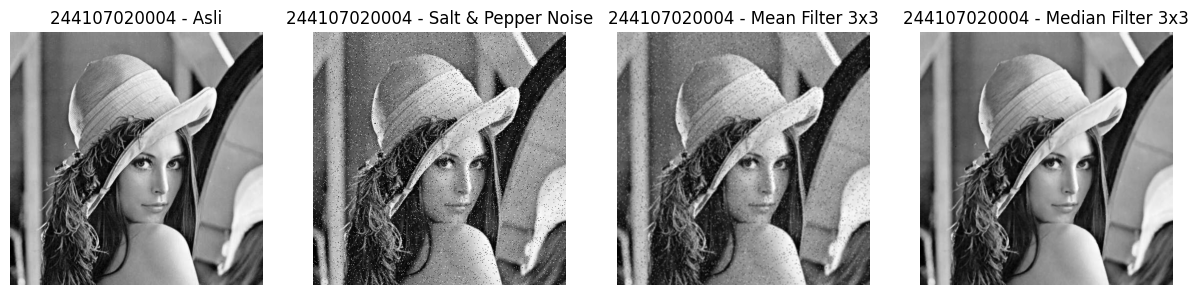

In [55]:
img = cv.imread('/content/drive/MyDrive/Semester 5/PCVK/images/lena.jpg')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Menambahkan noise Salt and Pepper
noisy = img_gray.copy()

prob = 0.05

random = np.random.random(img_gray.shape)

noisy[random < prob / 2] = 0
noisy[random > 1 - prob / 2] = 255

# Mean Filter 3x3
mean_filter = cv.blur(noisy, (3, 3))

# Median Filter 3x3
median_filter = cv.medianBlur(noisy, 3)

show_side_by_side(
    [img_gray, noisy, mean_filter, median_filter],
    [NIM+" - Asli",
     NIM+" - Salt & Pepper Noise",
     NIM+" - Mean Filter 3x3",
     NIM+" - Median Filter 3x3"]
)

Median Filter terlihat lebih bersih karena dapat menghilangkan bintik hitam putih tanpa terlalu merusak bentuk asli gambar. Sedangkan Mean Filter menghitung nilai rata-rata sehingga noise ikut tercampur dan gambar menjadi lebih blur/buram.

### **Tugas No 2**

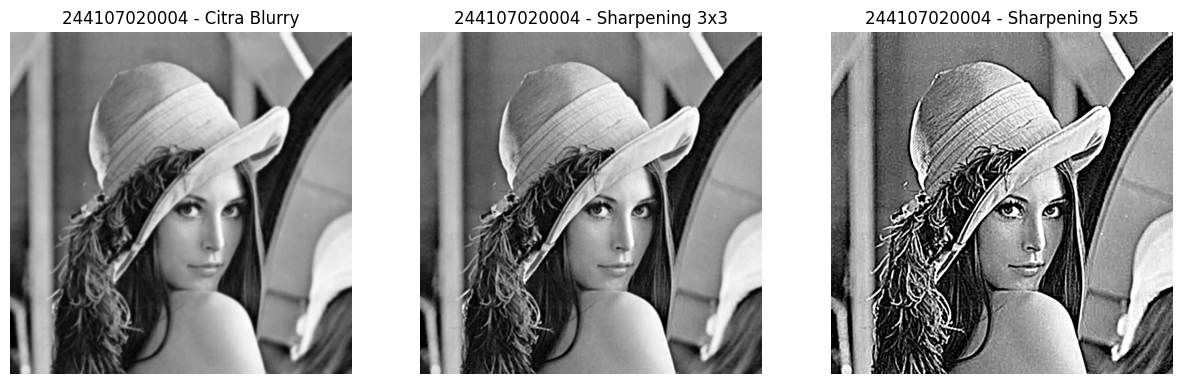

In [60]:
# Membuat citra sedikit buram
blurry = cv.GaussianBlur(img_gray, (5, 5), 0)

# Kernel Sharpening 3x3
kernel_3x3 = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
])

# Kernel Sharpening 5x5
kernel_5x5 = np.array([
    [0, 0, -1, 0, 0],
    [0, -1, -1, -1, 0],
    [-1, -1, 13, -1, -1],
    [0, -1, -1, -1, 0],
    [0, 0, -1, 0, 0]
])

# Terapkan sharpening 3x3
sharpen_3x3 = cv.filter2D(blurry, -1, kernel_3x3)

# Terapkan sharpening 5x5
sharpen_5x5 = cv.filter2D(blurry, -1, kernel_5x5)

show_side_by_side(
    [blurry, sharpen_3x3, sharpen_5x5],
    [NIM+" - Citra Blurry",
     NIM+" - Sharpening 3x3",
     NIM+" - Sharpening 5x5"]
)

*   **Sharpening 3x3**: Tepi gambar menjadi lebih jelas dan tajam. Noise/distorsi masih relatif sedikit sehingga gambar tetap terlihat natural.
*   **Sharpening 5x5**: Tepi terlihat jauh lebih tajam, tetapi beberapa bagian menjadi terlalu kontras dan muncul efek kasar/noise, terutama pada rambut dan detail wajah.

*  **Kesimpulan**: Berdasarkan hasil pengamatan, kernel 3x3 lebih optimal untuk digunakan sehari-hari karena memberikan keseimbangan antara ketajaman tepi dan kadar noise/distorsi. Kernel 5x5 lebih cocok jika membutuhkan efek penajaman yang lebih kuat.



### **Tugas No 3**

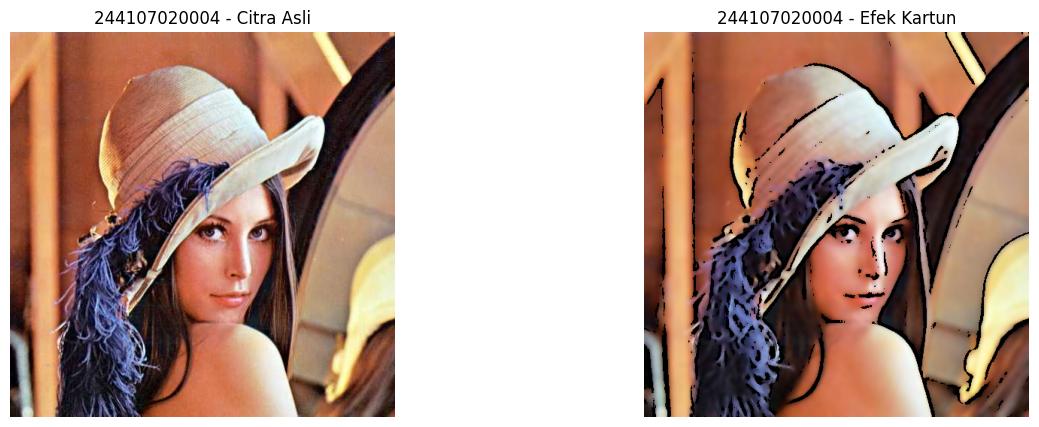

In [63]:
# Fungsi Kartun
def kartun(image):
    # Penghalusan warna dengan Bilateral Filter
    color = cv.bilateralFilter(image, d=9, sigmaColor=200, sigmaSpace=200)

    # Mengubah citra menjadi grayscale
    gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)

    # Menghaluskan grayscale
    gray_blur = cv.medianBlur(gray, 7)

    # Deteksi garis tepi dengan Adaptive Thresholding
    edges = cv.adaptiveThreshold(
        gray_blur,
        255,
        cv.ADAPTIVE_THRESH_MEAN_C,
        cv.THRESH_BINARY,
        9,
        9
    )

    # Menggabungkan warna dan garis tepi
    cartoon = cv.bitwise_and(color, color, mask=edges)

    return cartoon

# Membuat efek kartun
cartoon = kartun(img)

# Menampilkan perbandingan
show_side_by_side(
    [img, cartoon],
    [NIM+" - Citra Asli", NIM+" - Efek Kartun"]
)

Hasil efek kartun membuat warna pada citra menjadi lebih rata dan halus karena menggunakan Bilateral Filter. Garis tepi objek juga terlihat lebih jelas karena menggunakan Adaptive Thresholding. Setelah keduanya digabungkan, citra asli berubah menjadi tampilan seperti kartun dengan warna yang lebih sederhana dan garis tepi yang tegas.